# A Controlled Proof: Naive CV Fabricates Skill That Is Not There

Every other notebook here uses real data, where the true answer is
unknown. This one is synthetic on purpose: the target is built so that
**no feature can predict it**, so we know the right answer in advance.
That is what makes it a proof rather than a demonstration.

Deterministic and offline — no download, fixed seed.

## How the data is built

- `e` is i.i.d. Gaussian noise.
- The label `y[t] = mean(e[t : t + H])` is a forward window over that
  noise. It depends only on *future noise*, never on a feature, so the
  true predictive power of any feature for `y` is exactly zero. But
  neighbouring labels share `H - 1` of the same noise terms, so `y` is
  strongly autocorrelated — adjacent rows have almost the same label.
- The feature `x` is a steadily increasing quantity — a cumulative
  counter, think account age or running traded volume. It carries no
  information about `y`. It only rises with time, which is extremely
  common in real data and makes it, accidentally, a proxy for *when* a
  row is.

The best any honest model can do here is predict the mean, so an honest
out-of-sample score must never come out positive.

In [1]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor

from purgedcv import PurgedKFold
from purgedcv.diagnostics import compute_overlap_fraction

SEED = 0
N = 1000
H = 20  # label horizon: y[t] aggregates noise over the next H steps
N_SPLITS = 5

## Build the data

`y` is a forward window over pure noise — unrelated to `x` by
construction. `x` only increases with time.

In [2]:
rng = np.random.default_rng(SEED)

e = rng.standard_normal(N + H)
y = np.array([e[t : t + H].mean() for t in range(N)])  # depends only on noise

x = np.cumsum(rng.gamma(shape=2.0, scale=1.0, size=N))  # monotone, unrelated
features = x.reshape(-1, 1)

pred = pd.Series(pd.date_range("2020-01-01", periods=N, freq="D"))
evalu = pred + pd.Timedelta(days=H)

print(
    f"corr(x, y) = {np.corrcoef(x, y)[0, 1]:+.3f}  "
    "(spurious finite-sample value; the population relationship is 0 by construction)"
)

corr(x, y) = -0.217  (spurious finite-sample value; the population relationship is 0 by construction)


## Naive shuffled k-fold vs PurgedKFold

Shuffled k-fold scatters each row's temporal neighbours into the
training set. For a test row, training then holds rows with almost the
same `y` and a very close `x`, so a flexible model just reads the
neighbour's label back out. `PurgedKFold` removes the training rows
whose label window overlaps the test horizon. We also score a
predict-the-mean baseline as the ~0 reference.

In [3]:
naive = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
purged = PurgedKFold(
    n_splits=N_SPLITS,
    prediction_times=pred,
    evaluation_times=evalu,
    purge_horizon=f"{H}D",
    embargo=f"{H}D",
)

models = {
    "predict-the-mean": DummyRegressor(strategy="mean"),
    "k-NN": KNeighborsRegressor(n_neighbors=10),
    "RandomForest": RandomForestRegressor(n_estimators=120, random_state=SEED),
}

results = {}
for name, model in models.items():
    naive_r2 = float(cross_val_score(model, features, y, cv=naive, scoring="r2").mean())
    purged_r2 = float(cross_val_score(model, features, y, cv=purged, scoring="r2").mean())
    results[name] = {"naive_r2": naive_r2, "purged_r2": purged_r2}

print(f"{'model':<18}{'naive KFold R2':>16}{'PurgedKFold R2':>16}")
print("-" * 50)
for name, r in results.items():
    print(f"{name:<18}{r['naive_r2']:>16.3f}{r['purged_r2']:>16.3f}")

model               naive KFold R2  PurgedKFold R2
--------------------------------------------------
predict-the-mean            -0.012          -0.125
k-NN                         0.830          -1.311
RandomForest                 0.908          -1.943


## The mechanism: label-horizon overlap

Not just *that* it leaks, but *why*: the fraction of training rows
whose label window overlaps the test horizon.

In [4]:
def mean_overlap(splitter):
    fr = [compute_overlap_fraction(tr, te, pred, evalu) for tr, te in splitter.split(features, y)]
    return float(np.mean(fr))


naive_overlap = mean_overlap(naive)
purged_overlap = mean_overlap(purged)
print(f"naive shuffled KFold : {naive_overlap:.1%} of training rows leak")
print(f"PurgedKFold          : {purged_overlap:.1%} of training rows leak")

naive shuffled KFold : 100.0% of training rows leak
PurgedKFold          : 0.0% of training rows leak


## Visualising the collapse

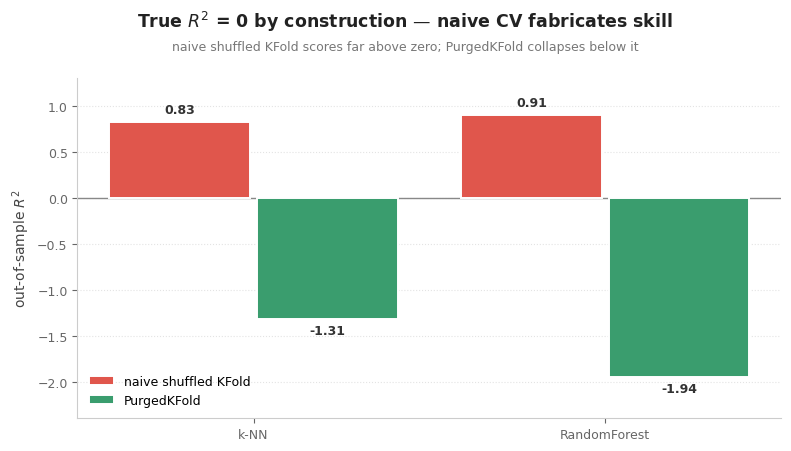

In [5]:
import matplotlib.pyplot as plt
from pathlib import Path

real = [m for m in results if m != "predict-the-mean"]
naive_vals = [results[m]["naive_r2"] for m in real]
purged_vals = [results[m]["purged_r2"] for m in real]
xpos = np.arange(len(real))

NAIVE, PURGED = "#e0564c", "#3a9d6e"

fig, ax = plt.subplots(figsize=(8, 4.6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bars_naive = ax.bar(xpos - 0.21, naive_vals, 0.40, label="naive shuffled KFold",
                    color=NAIVE, edgecolor="white", linewidth=1.4, zorder=3)
bars_purged = ax.bar(xpos + 0.21, purged_vals, 0.40, label="PurgedKFold",
                     color=PURGED, edgecolor="white", linewidth=1.4, zorder=3)

for bars in (bars_naive, bars_purged):
    for rect in bars:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width() / 2,
                h + (0.06 if h >= 0 else -0.06), f"{h:.2f}",
                ha="center", va="bottom" if h >= 0 else "top",
                fontsize=9, fontweight="bold", color="#333333")

ax.axhline(0.0, color="#888888", lw=1, zorder=2)
ax.set_xticks(xpos, real)
ax.set_ylim(min(purged_vals) - 0.45, max(naive_vals) + 0.4)
ax.set_ylabel("out-of-sample $R^2$", fontsize=10, color="#444444")
ax.tick_params(colors="#666666", labelsize=9)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#cccccc")
ax.grid(axis="y", ls=":", color="#dddddd", alpha=0.8, zorder=0)

fig.text(0.5, 0.95, "True $R^2$ = 0 by construction — naive CV fabricates skill",
         ha="center", fontsize=12.5, fontweight="bold", color="#222222")
fig.text(0.5, 0.90,
         "naive shuffled KFold scores far above zero; PurgedKFold collapses below it",
         ha="center", fontsize=9, color="#777777")
ax.legend(frameon=False, fontsize=9, loc="lower left")

fig.subplots_adjust(top=0.84, bottom=0.10, left=0.09, right=0.97)

# keep the README figure in sync with this notebook
out_dir = Path("../.github/images")
if out_dir.is_dir():
    fig.savefig(out_dir / "synthetic_leakage_proof.png", dpi=150)

plt.show()


## Dose–response: how much purging is enough?

The bar chart showed the *consequence*. This shows the *mechanism*, with
no model in the way. We hand `PurgedKFold` a range of assumed label
horizons and measure how much true label overlap still leaks into
training — `compute_overlap_fraction` scored against the real horizon
`H`. The residual leak falls linearly and reaches exactly zero the moment
the purge horizon reaches the true label horizon. Underestimate the
horizon by even a little and some leakage always remains, which is why
the purge horizon has to be set to at least the true label horizon.

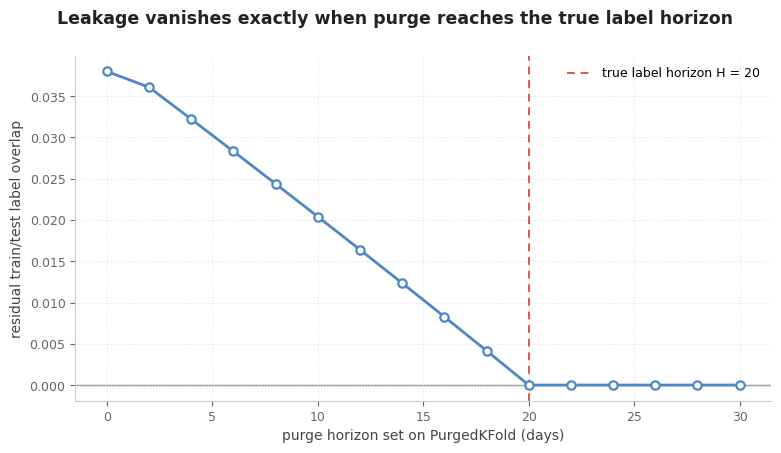

residual overlap at purge = 0  : 0.0380
residual overlap at purge = H  : 0.0000


In [6]:
horizons = list(range(0, int(1.5 * H) + 1, 2))
residual = []
for assumed in horizons:
    cv_p = PurgedKFold(
        n_splits=N_SPLITS,
        prediction_times=pred,
        evaluation_times=pred + pd.Timedelta(days=assumed),
    )
    fr = [
        compute_overlap_fraction(tr, te, pred, evalu)  # evalu = the TRUE horizon
        for tr, te in cv_p.split(features, y)
    ]
    residual.append(float(np.mean(fr)))

fig, ax = plt.subplots(figsize=(8, 4.6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.plot(horizons, residual, marker="o", color="#4f86c6", lw=2,
        markerfacecolor="white", markeredgecolor="#4f86c6",
        markeredgewidth=1.6, zorder=3)
ax.axvline(H, color="#e0564c", ls=(0, (4, 3)), lw=1.4,
           label=f"true label horizon H = {H}", zorder=2)
ax.axhline(0.0, color="#888888", lw=1, zorder=1)

ax.set_xlabel("purge horizon set on PurgedKFold (days)", fontsize=10, color="#444444")
ax.set_ylabel("residual train/test label overlap", fontsize=10, color="#444444")
ax.tick_params(colors="#666666", labelsize=9)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#cccccc")
ax.grid(ls=":", color="#dddddd", alpha=0.8, zorder=0)

fig.text(0.5, 0.95, "Leakage vanishes exactly when purge reaches the true label horizon",
         ha="center", fontsize=12.5, fontweight="bold", color="#222222")
ax.legend(frameon=False, fontsize=9)

fig.subplots_adjust(top=0.88, bottom=0.13, left=0.10, right=0.97)
plt.show()

print(f"residual overlap at purge = 0  : {residual[0]:.4f}")
print(f"residual overlap at purge = H  : {residual[horizons.index(H)]:.4f}")


## Verdict

On a target nothing can predict, naive shuffled k-fold lets k-NN and
RandomForest score far above the ~0 baseline. With 100% of training
rows overlapping the test labels, that skill is copied, not learned.

`PurgedKFold` drops the overlap to 0% and the fabricated skill
collapses: the models no longer beat — nor even match — the
predict-the-mean baseline. The exact negative number is not the point;
**no positive skill** is the correct answer here, and only the purged
split reports it.

This is the whole library in one controlled case: it does not make
models look better, it stops them looking better than they are.